In [1]:
import duckdb
import pandas as pd
from IPython.display import display
import os

# Create output directory for CSV files
os.makedirs("data", exist_ok=True)

con = duckdb.connect("market_data.db")
tables = con.execute("SHOW TABLES").df()
display(tables)

for t in tables['name'].tolist():
    print(f"\n=== {t} ===")
    
    # Get row count
    count = con.execute(f"SELECT COUNT(*) AS n FROM {t}").df().iloc[0]['n']
    print(f"rows: {count}")
    
    # Export table to CSV
    csv_filename = f"data/{t}.csv"
    con.execute(f"COPY {t} TO '{csv_filename}' (HEADER, DELIMITER ',')")
    print(f"✓ Exported to {csv_filename}")
    
    # Display sample (optional)
    sample = con.execute(f"SELECT * FROM {t}").df().tail(8)
    display(sample)

,name
0,binance_snapshots
1,live_trades
2,orderbook_snapshots
3,trade_resolutions



=== binance_snapshots ===
rows: 1687
✓ Exported to data/binance_snapshots.csv


,id,fetched_at,asset,bid,ask,mid,rsi,interval,source
1679,1773954910562712,2026-03-19 17:59:48.226900-04:00,XRP,1.4544,1.4549,1.45465,68.005181,1m,binance.us
1680,1773954910562713,2026-03-19 17:59:48.226900-04:00,BTC,70401.8800,70425.8200,70413.85000,44.397634,1m,binance.us
1681,1773954910562714,2026-03-19 17:59:48.226900-04:00,ETH,2149.7400,2150.2600,2150.00000,52.538631,1m,binance.us
1682,1773954910562715,2026-03-19 17:59:48.226900-04:00,SOL,89.1700,89.1800,89.17500,100.000000,1m,binance.us
1683,1773954910562716,2026-03-19 17:59:54.693943-04:00,XRP,1.4544,1.4549,1.45465,68.005181,1m,binance.us
1684,1773954910562717,2026-03-19 17:59:54.693943-04:00,BTC,70401.8800,70425.8200,70413.85000,44.397634,1m,binance.us
1685,1773954910562718,2026-03-19 17:59:54.693943-04:00,ETH,2149.7400,2150.2600,2150.00000,52.538631,1m,binance.us
1686,1773954910562719,2026-03-19 17:59:54.693943-04:00,SOL,89.1700,89.1800,89.17500,100.000000,1m,binance.us



=== live_trades ===
rows: 12
✓ Exported to data/live_trades.csv


,id,traded_at,market_ticker,side,contracts,limit_price_cents,is_dry_run,status,mid_at_entry,rsi_at_entry,client_order_id
4,1773954910561036,2026-03-19 17:33:00.827097-04:00,KXBTC15M-26MAR191745-45,yes,1,50,True,paper_trade,0.480,1.097950,KXBTC15M-26MAR191745-45-1773955984
5,1773954910561037,2026-03-19 17:33:00.827097-04:00,KXETH15M-26MAR191745-45,yes,1,52,True,paper_trade,0.500,38.834081,KXETH15M-26MAR191745-45-1773955985
6,1773954910561038,2026-03-19 17:33:00.827097-04:00,KXXRP15M-26MAR191745-45,no,1,58,True,paper_trade,0.450,100.000000,KXXRP15M-26MAR191745-45-1773955987
7,1773954910561039,2026-03-19 17:37:19.798711-04:00,KXSOL15M-26MAR191745-45,yes,1,35,True,paper_trade,0.325,0.000000,KXSOL15M-26MAR191745-45-1773956244
8,1773954910561040,2026-03-19 17:48:05.523486-04:00,KXXRP15M-26MAR191800-00,yes,1,51,True,paper_trade,0.485,27.586207,KXXRP15M-26MAR191800-00-1773956889
9,1773954910561041,2026-03-19 17:48:05.523486-04:00,KXETH15M-26MAR191800-00,no,1,42,True,paper_trade,0.605,63.839720,KXETH15M-26MAR191800-00-1773956889
10,1773954910561042,2026-03-19 17:48:05.523486-04:00,KXSOL15M-26MAR191800-00,yes,1,46,True,paper_trade,0.445,0.000000,KXSOL15M-26MAR191800-00-1773956891
11,1773954910561043,2026-03-19 17:51:09.903334-04:00,KXBTC15M-26MAR191800-00,yes,1,32,True,paper_trade,0.305,23.629725,KXBTC15M-26MAR191800-00-1773957074



=== orderbook_snapshots ===
rows: 1687
✓ Exported to data/orderbook_snapshots.csv


,id,fetched_at,market_ticker,asset,direction,yes_best_bid_dollars,yes_best_bid_qty,no_best_bid_dollars,no_best_bid_qty,mid_dollars,spread_dollars,yes_bids_json,no_bids_json
1679,1773954910562711,2026-03-19 17:59:48.226900-04:00,KXXRP15M-26MAR191800-00,XRP,UP,0.997,78.0,NaN,NaN,0.9970,NaN,"[[0, 150.0], [1, 224.0], [2, 66.0], [3, 1.0], ...",[]
1680,1773954910562712,2026-03-19 17:59:48.226900-04:00,KXETH15M-26MAR191800-00,ETH,UP,0.995,4.0,NaN,NaN,0.9950,NaN,"[[0, 400.0], [1, 264.0], [2, 66.0], [3, 1.0], ...",[]
1681,1773954910562713,2026-03-19 17:59:48.226900-04:00,KXBTC15M-26MAR191800-00,BTC,UP,NaN,NaN,0.999,2188.0,0.0010,NaN,[],"[[0, 900.0], [0, 75.0], [1, 620.0], [1, 75.0],..."
1682,1773954910562714,2026-03-19 17:59:48.226900-04:00,KXSOL15M-26MAR191800-00,SOL,UP,0.996,190.0,0.001,200.0,0.9975,0.003,"[[0, 200.0], [1, 224.0], [2, 68.0], [3, 1.0], ...","[[0, 200.0]]"
1683,1773954910562715,2026-03-19 17:59:54.693943-04:00,KXXRP15M-26MAR191800-00,XRP,UP,0.997,78.0,NaN,NaN,0.9970,NaN,"[[0, 150.0], [1, 224.0], [2, 66.0], [3, 1.0], ...",[]
1684,1773954910562716,2026-03-19 17:59:54.693943-04:00,KXETH15M-26MAR191800-00,ETH,UP,0.995,4.0,NaN,NaN,0.9950,NaN,"[[0, 400.0], [1, 254.0], [2, 66.0], [3, 1.0], ...",[]
1685,1773954910562717,2026-03-19 17:59:54.693943-04:00,KXBTC15M-26MAR191800-00,BTC,UP,NaN,NaN,0.994,190.0,0.0060,NaN,[],"[[0, 900.0], [1, 620.0], [2, 5.0], [3, 101.0],..."
1686,1773954910562718,2026-03-19 17:59:54.693943-04:00,KXSOL15M-26MAR191800-00,SOL,UP,0.996,188.0,0.001,200.0,0.9975,0.003,"[[0, 200.0], [1, 214.0], [2, 68.0], [3, 1.0], ...","[[0, 200.0]]"



=== trade_resolutions ===
rows: 12
✓ Exported to data/trade_resolutions.csv


,id,resolved_at,market_ticker,side,price_cents,contracts,result,outcome,profit_cents,is_dry_run
4,1773956704791367,2026-03-19 17:44:54.562374-04:00,KXBTC15M-26MAR191745-45,yes,50,1,no,LOSS,-50,True
5,1773956705783136,2026-03-19 17:44:54.562374-04:00,KXETH15M-26MAR191745-45,yes,52,1,yes,WIN,48,True
6,1773956706700831,2026-03-19 17:44:54.562374-04:00,KXXRP15M-26MAR191745-45,no,58,1,no,WIN,42,True
7,1773956707578809,2026-03-19 17:44:54.562374-04:00,KXSOL15M-26MAR191745-45,yes,35,1,no,LOSS,-35,True
8,1773957603500776,2026-03-19 17:59:54.693943-04:00,KXXRP15M-26MAR191800-00,yes,51,1,no,LOSS,-51,True
9,1773957604713499,2026-03-19 17:59:54.693943-04:00,KXETH15M-26MAR191800-00,no,42,1,no,WIN,58,True
10,1773957606003765,2026-03-19 17:59:54.693943-04:00,KXSOL15M-26MAR191800-00,yes,46,1,yes,WIN,54,True
11,1773957606985073,2026-03-19 17:59:54.693943-04:00,KXBTC15M-26MAR191800-00,yes,32,1,no,LOSS,-32,True


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "#0E1117",
    "axes.facecolor": "#0E1117",
    "savefig.facecolor": "#0E1117",
    "axes.edgecolor": "#2A2E39",
    "grid.color": "#2A2E39",
    "text.color": "#DADADA",
    "axes.labelcolor": "#DADADA",
    "xtick.color": "#B0B0B0",
    "ytick.color": "#B0B0B0",
})

RSI_PERIOD = 14

def compute_rsi_series(prices: pd.Series, period: int = 14) -> pd.Series:
    delta = prices.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def plot_trade(ticker: str):
    # Load data as pandas DataFrames (via duckdb -> pandas)
    trade = con.execute(
        """
        SELECT *
        FROM live_trades
        WHERE market_ticker = ?
        ORDER BY traded_at
        LIMIT 1
        """,
        [ticker],
    ).df()

    if trade.empty:
        raise ValueError(f"No live_trades row found for {ticker}")

    trade_time = pd.to_datetime(trade.loc[0, "traded_at"])
    limit_price = trade.loc[0, "limit_price_cents"] / 100.0

    resolution = con.execute(
        """
        SELECT *
        FROM trade_resolutions
        WHERE market_ticker = ?
        ORDER BY resolved_at
        LIMIT 1
        """,
        [ticker],
    ).df()

    resolved_time = None
    profit_cents = None
    outcome = None
    if not resolution.empty:
        resolved_time = pd.to_datetime(resolution.loc[0, "resolved_at"])
        profit_cents = resolution.loc[0, "profit_cents"]
        outcome = resolution.loc[0, "outcome"]

    kalshi = con.execute(
        """
        SELECT fetched_at, mid_dollars, yes_best_bid_dollars, no_best_bid_dollars
        FROM orderbook_snapshots
        WHERE market_ticker = ?
        ORDER BY fetched_at
        """,
        [ticker],
    ).df()

    if not kalshi.empty:
        kalshi["fetched_at"] = pd.to_datetime(kalshi["fetched_at"])
        kalshi_min = kalshi["fetched_at"].min()
        kalshi_max = kalshi["fetched_at"].max()
        print(f"Kalshi snapshots: {len(kalshi)} | {kalshi_min} -> {kalshi_max}")
        if kalshi_max <= trade_time:
            print("Note: Kalshi data ends at or before entry; no post-entry orderbook snapshots found for this ticker.")
    else:
        print(f"No orderbook snapshots found for {ticker}")

    # Build full trading window based on Kalshi data + resolution time
    if not kalshi.empty:
        start_time = kalshi["fetched_at"].min()
        end_time = kalshi["fetched_at"].max()
    else:
        start_time = trade_time
        end_time = trade_time

    if resolved_time is not None and resolved_time > end_time:
        end_time = resolved_time

    eth = con.execute(
        """
        SELECT fetched_at, mid
        FROM binance_snapshots
        WHERE asset = 'ETH'
          AND fetched_at BETWEEN ? AND ?
        ORDER BY fetched_at
        """,
        [start_time, end_time],
    ).df()

    if eth.empty:
        print(f"No ETH binance snapshots found in window {start_time} to {end_time}")
    else:
        eth["fetched_at"] = pd.to_datetime(eth["fetched_at"])

    # Recompute RSI from ETH mid (smoother than cached 1m RSI)
    if not eth.empty and eth["mid"].notna().any():
        eth["rsi_calc"] = compute_rsi_series(eth["mid"], RSI_PERIOD)
    else:
        eth["rsi_calc"] = None

    # Nearest values at entry
    entry_kalshi_mid = None
    entry_eth_mid = None
    entry_rsi = None

    if not kalshi.empty:
        kalshi_sorted = kalshi.sort_values("fetched_at")
        entry_row = kalshi_sorted[kalshi_sorted["fetched_at"] <= trade_time]
        entry_kalshi_mid = entry_row["mid_dollars"].iloc[-1] if not entry_row.empty else kalshi_sorted["mid_dollars"].iloc[0]

    if not eth.empty:
        eth_sorted = eth.sort_values("fetched_at")
        eth_entry_row = eth_sorted[eth_sorted["fetched_at"] <= trade_time]
        entry_eth_mid = eth_entry_row["mid"].iloc[-1] if not eth_entry_row.empty else eth_sorted["mid"].iloc[0]
        if "rsi_calc" in eth_sorted.columns:
            entry_rsi = eth_entry_row["rsi_calc"].iloc[-1] if not eth_entry_row.empty else eth_sorted["rsi_calc"].iloc[0]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Color palette
    kalshi_color = "#4C78A8"
    no_bid_color = "#F2C6A0"
    eth_color = "#4C78A8"
    rsi_color = "#F58518"

    # Top: Kalshi price (signal for entry)
    ax = axes[0]
    if not kalshi.empty:
        ax.plot(kalshi["fetched_at"], kalshi["mid_dollars"], color=kalshi_color)
        ax.plot(kalshi["fetched_at"], kalshi["no_best_bid_dollars"], alpha=0.35, color=no_bid_color)
    ax.axvline(trade_time, color="#888888", linestyle="--", alpha=0.8)
    ax.axhline(limit_price, color="#EF5350", linestyle=":")

    # Entry circle at limit price with annotation
    ax.scatter([trade_time], [limit_price], s=90, color="#EF5350", edgecolors="#FFFFFF", linewidths=1.0, zorder=5)
    entry_side = trade.loc[0, "side"].upper()
    entry_label = f"Entry {entry_side}: ${limit_price:.2f}"
    if entry_kalshi_mid is not None:
        entry_label += f""
    ax.annotate(entry_label, (trade_time, limit_price),
                textcoords="offset points", xytext=(3, 12),
                fontsize=10, color="#FF4646")

    # Resolution circle with P&L label
    if resolved_time is not None:
        if not kalshi.empty:
            kalshi_sorted = kalshi.sort_values("fetched_at")
            resolved_row = kalshi_sorted[kalshi_sorted["fetched_at"] <= resolved_time]
            resolved_price = resolved_row["mid_dollars"].iloc[-1] if not resolved_row.empty else kalshi_sorted["mid_dollars"].iloc[-1]
        else:
            resolved_price = limit_price

        ax.scatter([resolved_time], [resolved_price], s=90, color="#AB47BC", edgecolors="#FFFFFF", linewidths=1.0, zorder=5)
        if profit_cents is not None:
            pnl_text = f"P&L ${profit_cents/100:.2f} ({outcome})"
            ax.annotate(pnl_text, (resolved_time, resolved_price),
                        textcoords="offset points", xytext=(8, 8),
                        fontsize=10, color="#DADADA")

    ax.set_ylabel("Kalshi Orderbook")

    # Middle: ETH Binance spot price
    ax = axes[1]
    if not eth.empty:
        ax.plot(eth["fetched_at"], eth["mid"], color=eth_color)
    ax.axvline(trade_time, color="#888888", linestyle="--", alpha=0.8)
    if entry_eth_mid is not None:
        ax.scatter([trade_time], [entry_eth_mid], s=70, color="#0077FF", edgecolors="#FFFFFF", linewidths=1.0, zorder=5)
        ax.annotate(f"Entry ETH ${entry_eth_mid:.2f}", (trade_time, entry_eth_mid),
                    textcoords="offset points", xytext=(3, 12),
                    fontsize=10, color="#0077FF")
    ax.set_ylabel("Binance ETHUSD")

    # Bottom: RSI
    ax = axes[2]
    if not eth.empty:
        ax.plot(eth["fetched_at"], eth["rsi_calc"], color=rsi_color)
    ax.axvline(trade_time, color="#888888", linestyle="--", alpha=0.8)
    ax.axhline(65, color="#EF5350", linestyle=":", alpha=0.7)
    ax.axhline(35, color="#66BB6A", linestyle=":", alpha=0.7)
    if entry_rsi is not None:
        ax.scatter([trade_time], [entry_rsi], s=70, color="#EF5350", edgecolors="#FFFFFF", linewidths=1.0, zorder=5)
        ax.annotate(f"Entry RSI {entry_rsi:.1f}", (trade_time, entry_rsi),
                    textcoords="offset points", xytext=(3, 12),
                    fontsize=10, color="#EF5350")
    ax.set_ylabel("ETHUSD RSI (1Min)")
    ax.set_xlabel("Time")

    entry_rsi_text = "n/a"
    if entry_rsi is not None:
        entry_rsi_text = f"{entry_rsi:.1f}"

    pnl_text = "P&L: n/a"
    if profit_cents is not None:
        pnl_text = f"P&L: ${profit_cents/100:.2f} ({outcome})"

    fig.suptitle(
        f"Market Ticker: {ticker} \n Kalshi Entry: ${limit_price:.2f}  | RSI Entry: {entry_rsi_text} \n  {pnl_text}"
    )
    plt.tight_layout()

    # Save image as PNG
    png_path = f"{ticker}_full_plot.png"
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {png_path}")

Kalshi snapshots: 138 | 2026-03-19 17:30:12.213371-04:00 -> 2026-03-19 17:44:54.562374-04:00


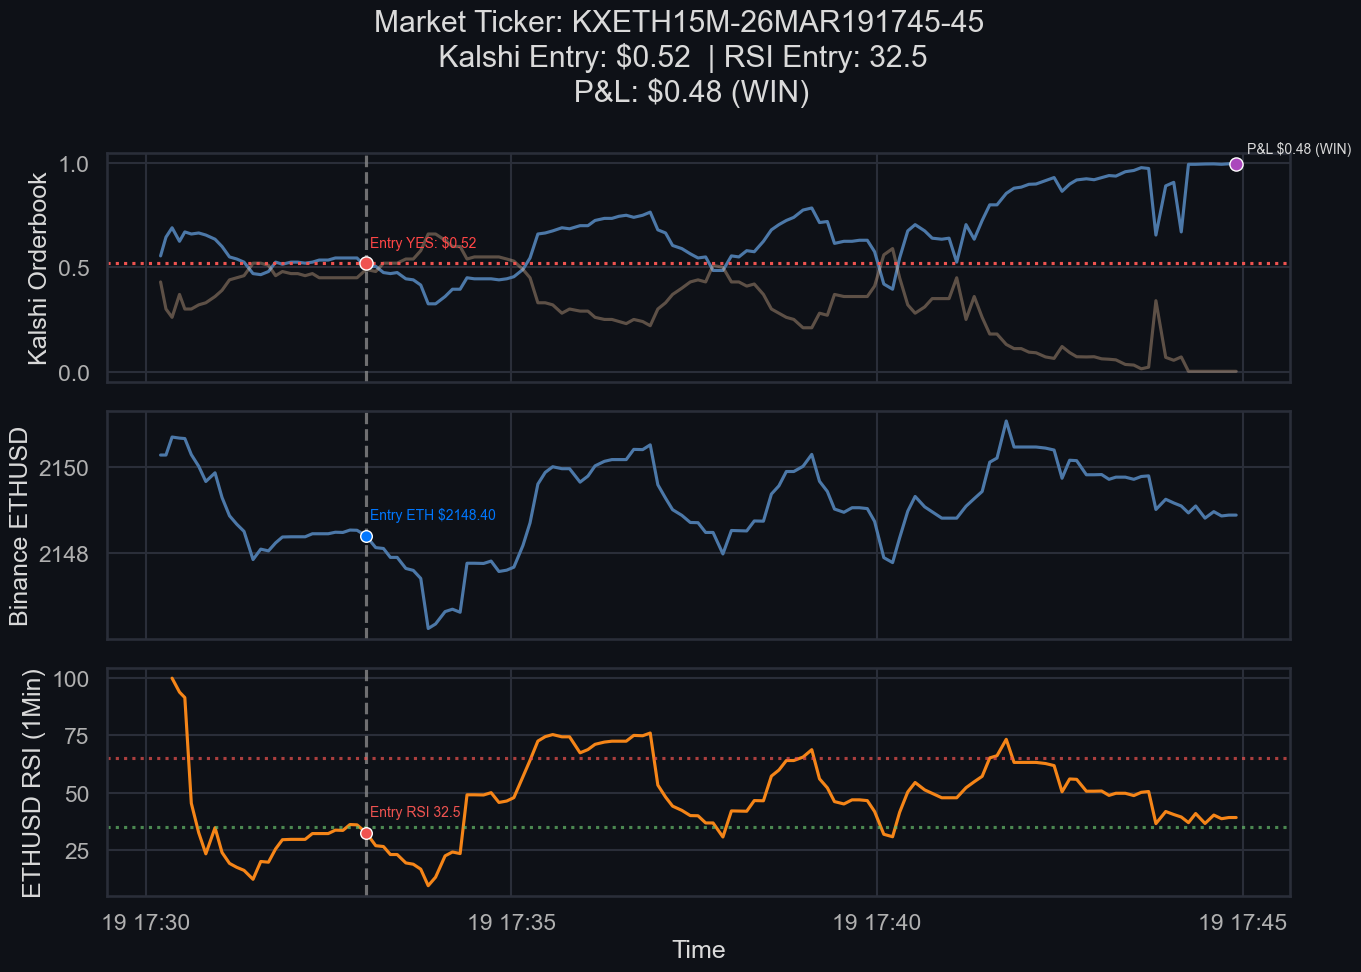

Saved plot to KXETH15M-26MAR191745-45_full_plot.png


In [3]:
# Visualize Trade
ticker = "KXETH15M-26MAR191745-45"
plot_trade(ticker)

In [4]:
con.close()